# Генеративные нейросети
## Задание 7

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.





**Баллы за задание:**
* Задача 1 — 130 баллов.
* Задача 2 — 80 баллов.


-----------


In [ ]:
# Bot check

# HW_ID: ds_gen7
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована
...

In [ ]:
!pip install pyro-ppl

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sns.set(palette="Set2", font_scale=1.3)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import FashionMNIST, MNIST
from torchvision import transforms
import torchvision.transforms.functional as TF

import pyro
from pyro.optim import Adam
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.nn import PyroModule, PyroSample
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.distributions import constraints


from scipy.stats import gaussian_kde

from IPython.display import clear_output
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd

---
### Задача 1
В этой задаче вы проверите теорию на практике и реализуете диффузионнную модель с непрерывным временем.

**1.** Выпишите формулы вариационного распределения $X_t|X_0$, скор-функции, семплирования для СДУ и ОДУ.

**2.** Положим, $\beta_t = \beta_0 + \lambda t$, где $\beta_0 = 0.01$, $\lambda=20$, $t\in[0, 1]$. Визуализируйте зависимость от $t$ коэффициента при $X_0$ в параметре сдвига распределения $X_t|X_0$ и параметра масштаба вариационного распределения $X_t|X_0$.

**3.**  Будем использовать простой двумерный датасет. Код генерации данных представлен ниже. Визуализируйте процесс зашумления данных для моментов времени $t$ равномерно выбранных на отрезке $[0, 1]$.

In [ ]:
# Количество точек в данных
data_size = 2000

# Данные
x = torch.linspace(-2.2, 2.2, data_size // 2).view((-1, 1))
data1 = torch.cat([x * 2, (torch.exp(x + 2) + 3 * x + 2) / 18], 1)
data2 = torch.cat([x * 2, (-torch.exp(-x + 2) + 3 * x - 2) / 18], 1)
data = torch.cat([data1, data2])
data += torch.randn(data.shape) * 0.04

# Метки
labels = torch.zeros(data_size).view((-1, 1))
labels[data_size // 2:] = 1

# Визуализация
pallete = sns.color_palette("Set2")
colors = [pallete[0]] * (data_size // 2) + [pallete[1]] * (data_size // 2)
plt.figure(figsize=(7, 7))
plt.scatter(data[:, 0], data[:, 1], s=5, c=colors)
plt.title("Простой датасет");

**4.** Обучите диффузионную модель с непрерывным временем на простом датасете. 
* Обучение может занять много времени &mdash; используйте много итераций.
* Вам может понадобиться клип градиентов модели.
* Визуализуйте лосс. Он будет очень шумным. Используйте лог-масштаб по оси y.

**5.** Визуализируйте результат генерации модели для 1000, 100 и 50 шагов в режиме семплирования СДУ.

**6.** Визуализируйте результат генерации модели для 1000, 100 и 50 шагов в режиме семплирования ОДУ.

**7.** Оцените логарифм плотности для объектов двумерной сетки и визуализируйте его.

**8.** Сделайте выводы.

**9.** Обучите модель на датасете MNIST. Обучение может занять очень много времени. Возможно, вам будет полезно поиграться с настройками обучения: шедулер скорости обучения, клип градиентов, регуляризация весов, &mdash;  выбора $t$ при обучении, усреднение весов [EMA](https://pytorch.org/docs/stable/optim.html#weight-averaging-swa-and-ema) и т.д. Визуализируйте лосс аналогично п. 4.

**10.** Визуализируйте результаты обучения модели. Также оцените плотность некоторых объектов обучающей выборки. Какие объекты имеют большую плотность, какие &mdash; меньшую?

---
### Задача 2
Научите модель генерировать заданный объект где угодно и как угодно.

In [ ]:
import os
import torch
import numpy as np
import random
import logging

from diffusers import AutoPipelineForText2Image
from huggingface_hub import hf_hub_download
from diffusers import StableDiffusionPipeline, ControlNetModel, UniPCMultistepScheduler
from diffusers import StableDiffusion3Pipeline
from diffusers import DiffusionPipeline
from diffusers import FluxPipeline
import torch
from PIL import Image
import time
from datetime import datetime, timedelta

device = "cuda"

**1.** В качестве объекта возьмите одного из героев советского мультфильма "Зима в Простоквашино" &mdash; кота Матроскина. Выберите модель Stable Diffusion или SDXL (скорее всего с ней будет проще разобраться дальше). Проверьте, может ли она генерировать изображения кота Матроскина.

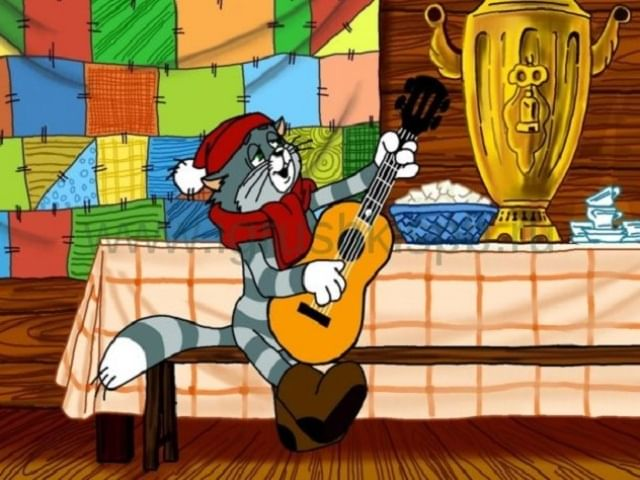

In [ ]:
_step_times = []
_start_time = None

def progress_callback(pipeline, step, timestep, callback_kwargs):
    global _start_time, _step_times
    
    if step == 0:
        _start_time = time.time()
        _step_times = []
        print("🚀 Starting diffusion process...")
    
    current_time = time.time()
    elapsed = current_time - _start_time
    
    if step > 0:
        step_duration = current_time - _step_times[-1]
        _step_times.append(step_duration)
    else:
        _step_times.append(0)
    
    remaining = 0
    if step > 0:
        recent_steps = _step_times[-min(5, len(_step_times)):]
        avg_step_time = sum(recent_steps) / len(recent_steps)
        remaining_steps = 40 - (step + 1)
        remaining = avg_step_time * remaining_steps
    
    elapsed_str = str(timedelta(seconds=int(elapsed)))[:7]
    remaining_str = str(timedelta(seconds=int(remaining)))[:7] if remaining > 0 else "00:00"
    
    latents = callback_kwargs.get("latents", None)
    if latents is not None:
        std = latents.std().item()
        noise_scale = timestep.item() / 1000.0
        
        progress = (step + 1) / 40
        bar_length = 30
        filled = int(bar_length * progress)
        bar = "█" * filled + "░" * (bar_length - filled)
        
        print(f"\rStep {step+1:02d}/40 [{bar}] {progress*100:3.0f}% | "
              f"Timestep: {timestep:4.0f} | Noise: {noise_scale:.3f} | "
              f"Elapsed: {elapsed_str} | ETA: {remaining_str}", end="")
    
    return callback_kwargs

In [ ]:
pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    use_safetensors=True,
).to(device)

pipe.vae = pipe.vae.to(dtype=torch.float16)
pipe.vae.enable_tiling()

In [ ]:
torch.cuda.empty_cache()
prompt = "Кот Матрскин"
image = pipe(
    prompt=prompt,
    num_inference_steps=40,
    height=1024,
    width=1024,
    callback_on_step_end=progress_callback,
).images[0]

image.save("lan_club.png")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/40 [00:00<?, ?it/s]

AttributeError: 'builtin_function_or_method' object has no attribute 'time'

**2.** Обучите модель выбранную на изображениях с котом Матроскиным.

Обучение предполагается провести с помощью метода [Dream Booth](https://arxiv.org/abs/2208.12242). Метод работает следующим образом. 
* Вы задаете специальный токен для выбранного объекта, например `[V]`. 
* Делаете описания для нескольких примеров изображений объекта с помощью этого токена. 
* Дообучаете диффузионную модель с помощью лосса реконструкции, который сравнивает исходные изображения с генерацией, а также лосса сохранности, сравнивающего генерации новой модели для промптов без нового токена с генерациями исходной модели. Причем дообучение происходит с не всей модели целиком, а с помощью [LoRA](https://habr.com/ru/articles/747534/).

Схема обучения показана ниже. Более подробное описание метода на русском можно найти [здесь](https://habr.com/ru/articles/760920/).

Изображения с котом Матроскиным уже подготовлены специально для вас и лежат [здесь](https://disk.yandex.ru/d/ANMyV9ol8lbpQQ). Картинки были получены следующим образом: сначала были сделаны скриншоты кадров с нашим героем, а затем вырезаны области с котом с помощью [демо модели SAM](https://segment-anything.com/demo).

С практической точки зрения вам может помочь вот этот [пример](https://colab.research.google.com/github/huggingface/notebooks/blob/main/diffusers/SDXL_DreamBooth_LoRA_.ipynb) (не пропустите его).



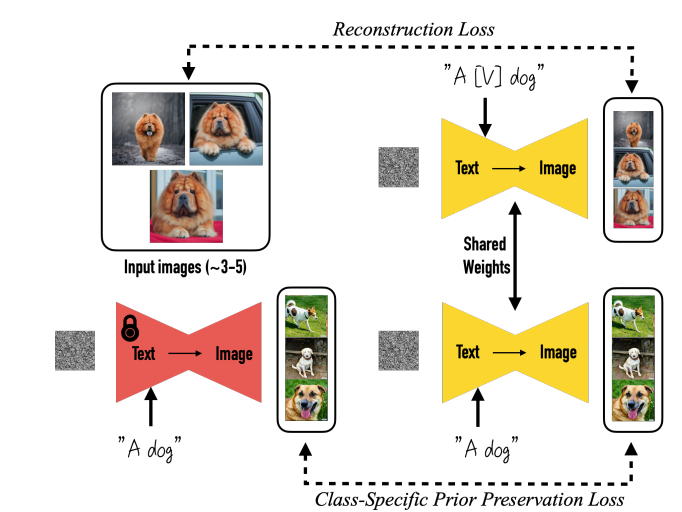

**3.** Сделайте несколько генераций с Матроскиным в разных локациях, с разными атрибутами. Оцените визуально качество дообучения.

**4.** Сгенерируйте изображения, используя те же промпты, что предыдущем пункте, только уберите из них токен, соответствующий Матроскину, заменив его на кота. Оцените качество сохранности модели.

**5.** Обучите модель с двумя разными весами для лосса сохранности, за него отвечает параметр `prior_loss_weight`. Оцените качество генераций аналогично пунктам 3 и 4. Сделайте вывод о влиянии этого лосса на итоговый результат.

**6.** Если качество генераций ни в одном из экспериментов не получилось удовлетворительным, предложите свои варианты решения проблемы и реализуйте их. Это может быть, например, предобработка изображений, уточнение промптов, подкрутка параметров обучения модели.

**7.**
Оцените как сильно изменились параметры лучшей модели до и после дообучения. Определите слои, в которых веса модели поменялись больше всего. Как можно интерпретировать полученный результат?


**Выводы:** 

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока